In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

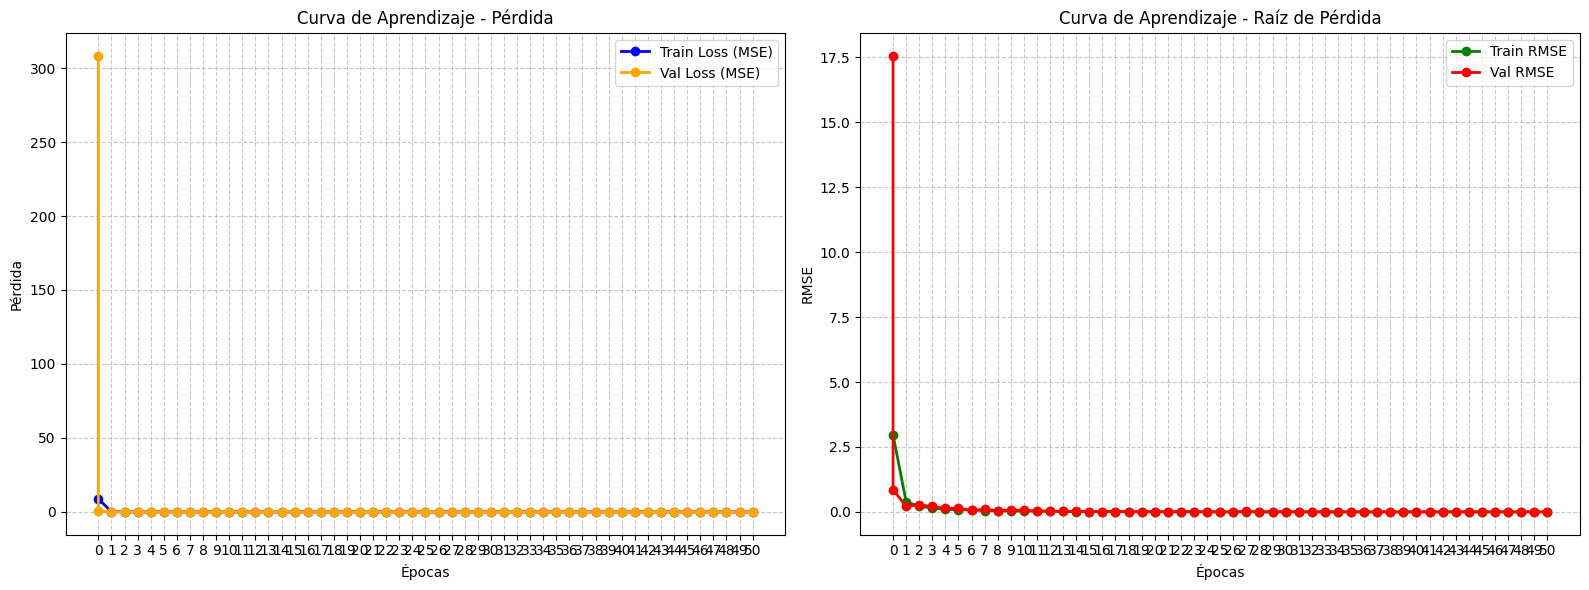

In [2]:
# 1. Definir la ruta de la carpeta (reemplazá con tu ruta real si varía)
base_dir = Path("logs/unet/20260528212020/run_20260528212020")
train_file = base_dir / "avg_train_losses.txt"
val_file = base_dir / "avg_val_losses.txt"

# Función para leer los archivos .txt y extraer epoch y loss
def cargar_perdidas_txt(ruta_archivo):
    epochs = []
    losses = []
    if not ruta_archivo.exists():
        print(f"Advertencia: No se encontró el archivo en {ruta_archivo}")
        return epochs, losses
    
    with open(ruta_archivo, "r") as f:
        for linea in f:
            linea = linea.strip()
            if linea and ":" in linea:
                parts = linea.split(":")
                epochs.append(int(parts[0]))     # El número antes del ':' es la época
                losses.append(float(parts[1]))   # El número después es la pérdida
    return epochs, losses

# 2. Cargar los datos de los textos
train_epochs, train_mse = cargar_perdidas_txt(train_file)
val_epochs, val_mse = cargar_perdidas_txt(val_file)

if not train_epochs and not val_epochs:
    raise FileNotFoundError("No se pudieron cargar datos de ninguno de los dos archivos .txt.")

# 3. Calcular RMSE
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

# 4. Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Pérdida (MSE)
if train_epochs:
    ax1.plot(train_epochs, train_mse, label='Train Loss (MSE)', color='blue', linewidth=2, marker='o')
if val_epochs:
    ax1.plot(val_epochs, val_mse, label='Val Loss (MSE)', color='orange', linewidth=2, marker='o')
ax1.set_title('Curva de Aprendizaje - Pérdida')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida')
# Forzamos a que el eje X muestre números enteros de las épocas actuales
ax1.set_xticks(train_epochs if train_epochs else val_epochs)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Grafico 2: RMSE
if train_epochs:
    ax2.plot(train_epochs, train_rmse, label='Train RMSE', color='green', linewidth=2, marker='o')
if val_epochs:
    ax2.plot(val_epochs, val_rmse, label='Val RMSE', color='red', linewidth=2, marker='o')
ax2.set_title('Curva de Aprendizaje - Raíz de Pérdida')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('RMSE')
ax2.set_xticks(train_epochs if train_epochs else val_epochs)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

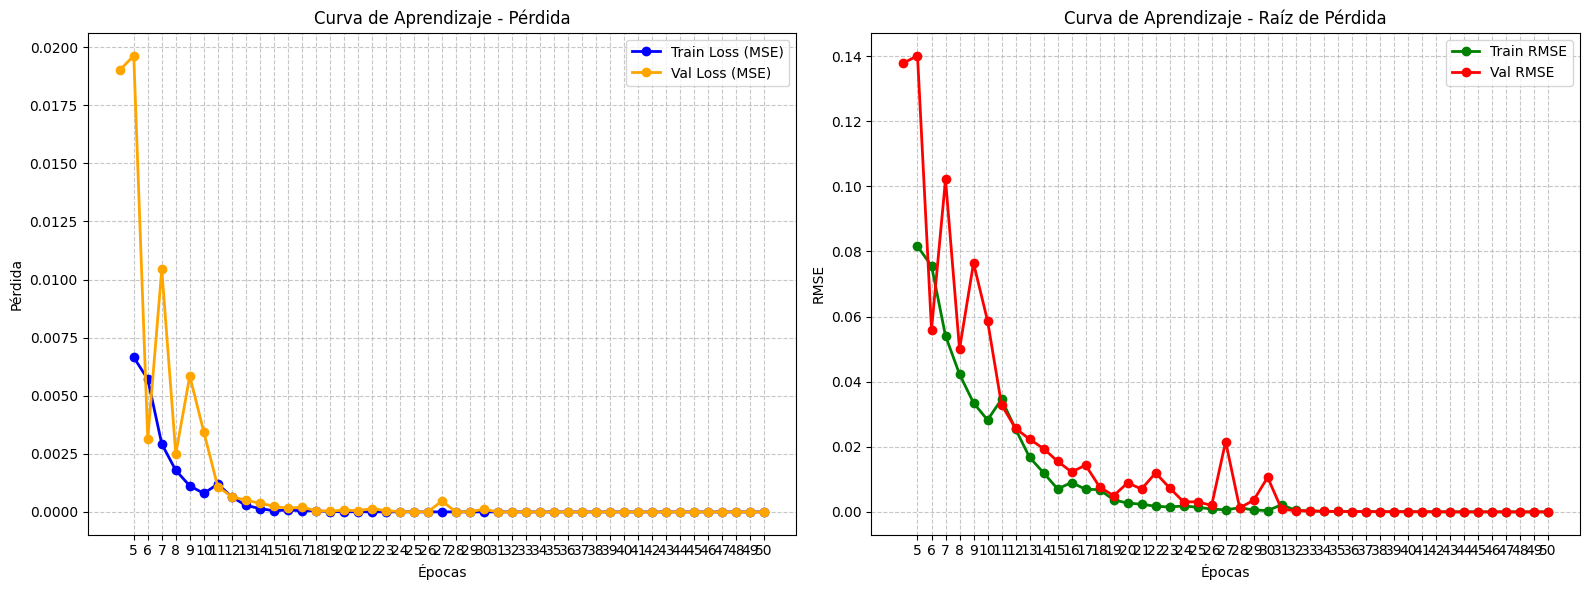

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Definir la ruta de la carpeta (reemplazá con tu ruta real si varía)
base_dir = Path("logs/unet/20260528212020/run_20260528212020")
train_file = base_dir / "avg_train_losses.txt"
val_file = base_dir / "avg_val_losses.txt"

# Función para leer los archivos .txt y extraer epoch y loss
def cargar_perdidas_txt(ruta_archivo):
    epochs = []
    losses = []
    if not ruta_archivo.exists():
        print(f"Advertencia: No se encontró el archivo en {ruta_archivo}")
        return epochs, losses
    
    with open(ruta_archivo, "r") as f:
        for linea in f:
            linea = linea.strip()
            if linea and ":" in linea:
                parts = linea.split(":")
                epochs.append(int(parts[0]))     # El número antes del ':' es la época
                losses.append(float(parts[1]))   # El número después es la pérdida
    return epochs, losses

# 2. Cargar los datos de los textos
train_epochs, train_mse = cargar_perdidas_txt(train_file)
val_epochs, val_mse = cargar_perdidas_txt(val_file)

if not train_epochs and not val_epochs:
    raise FileNotFoundError("No se pudieron cargar datos de ninguno de los dos archivos .txt.")

# --- NUEVO CÓDIGO: RECORTAR LOS PRIMEROS EPOCHS ---
ignorar_primeros = 5  # <--- CAMBIÁ ESTE NÚMERO a la cantidad de epochs iniciales que quieras omitir

if train_epochs:
    train_epochs = train_epochs[ignorar_primeros:]
    train_mse = train_mse[ignorar_primeros:]
if val_epochs:
    val_epochs = val_epochs[ignorar_primeros:]
    val_mse = val_mse[ignorar_primeros:]
# --------------------------------------------------

# 3. Calcular RMSE (al usar np.sqrt sobre las listas recortadas, el array resultante ya estará recortado)
train_rmse = np.sqrt(train_mse) if train_epochs else []
val_rmse = np.sqrt(val_mse) if val_epochs else []

# 4. Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Pérdida (MSE)
if train_epochs:
    ax1.plot(train_epochs, train_mse, label='Train Loss (MSE)', color='blue', linewidth=2, marker='o')
if val_epochs:
    ax1.plot(val_epochs, val_mse, label='Val Loss (MSE)', color='orange', linewidth=2, marker='o')
ax1.set_title('Curva de Aprendizaje - Pérdida')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida')
# Forzamos a que el eje X muestre números enteros de las épocas actuales
ax1.set_xticks(train_epochs if train_epochs else val_epochs)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Grafico 2: RMSE
if train_epochs:
    ax2.plot(train_epochs, train_rmse, label='Train RMSE', color='green', linewidth=2, marker='o')
if val_epochs:
    ax2.plot(val_epochs, val_rmse, label='Val RMSE', color='red', linewidth=2, marker='o')
ax2.set_title('Curva de Aprendizaje - Raíz de Pérdida')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('RMSE')
ax2.set_xticks(train_epochs if train_epochs else val_epochs)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()